In [112]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display, Markdown
from sklearn.neighbors import KNeighborsClassifier


In [113]:
df = pd.read_csv('train-2.csv')

In [114]:
class DataPreprocessor:
    """
    A class to preprocess data for machine learning models.
    """

    def __init__(self, df):
        """
        Make a copy of the input dataframe.

        Parameters
        ----------
        df : pandas.DataFrame
            The dataframe to preprocess.
        """
        self.df = df.copy()
    
    def age_to_int(self):
        """
        Converts the 'age' column to integer.
        """
        self.df['age'] = self.df['age'].astype(int)
        return self.df

    def drop_not_needed_columns(self):
        self.df.loc[(self.df['work_type_children'] == True) & (self.df['stroke'] == True), 'work_type_Govt_job'] = True

        self.df = self.df[self.df['gender_Other'] == 0]
        
        self.df.drop(['gender_Other', 'work_type_Never_worked', 'work_type_children'], axis=1, inplace=True)
        return self.df


    def preprocess_gender(self):
        """
        Processes gender columns.

        Converts 'gender_Female' and 'gender_Male' columns into a single
        'gender' column with binary values: 0 for Female and 1 for Male.
        Filters out rows where 'gender_Other' is 1.
        """
        self.df['gender'] = self.df.apply(
            lambda row: 0 if row['gender_Female'] else 1,
            axis=1
        )
        self.df.drop(['gender_Female', 'gender_Male'], axis=1, inplace=True)
        return self.df
    
    def preprocess_ever_married(self):
        """
        Converts 'ever_married' columns to a single 'ever_married' column.

        The new column has binary values: 1 for Yes and 0 for No.
        """
        self.df['ever_married'] = self.df.apply(
            lambda row: 1 if row['ever_married_Yes'] else 0,
            axis=1
        )
        self.df.drop(['ever_married_No', 'ever_married_Yes'], axis=1, inplace=True)
        return self.df
    
    def preprocess_residence_type(self):
        """
        Converts residence type columns to a single 'residence_type' column.

        The new column has binary values: 0 for Rural and 1 for Urban.
        """
        self.df['residence_type'] = self.df.apply(
            lambda row: 0 if row['Residence_type_Rural'] else 1,
            axis=1
        )
        self.df.drop(['Residence_type_Rural', 'Residence_type_Urban'], axis=1, inplace=True)
        return self.df
    
    def preprocess_work_type(self):
        """
        Converts work type columns and creates a 'work_type_self_employed' column.

        The new column has binary values: 1 if self-employed, else 0.
        """
        self.df['work_type_self_employed'] = self.df.apply(
            lambda row: 1 if row['work_type_Self-employed'] else 0,
            axis=1
        )
        self.df.drop(['work_type_Govt_job', 'work_type_Private',
                      'work_type_Self-employed'], axis=1, inplace=True)
        return self.df
    
    def convert_bool_to_int(self):
        """
        Converts boolean columns to integer type.
        """
        self.df[self.df.select_dtypes(include='bool').columns] = self.df.select_dtypes(include='bool').astype(int)
        return self.df
    
    def drop_columns(self, columns):
        """
        Drops specified columns from the dataframe.

        Parameters
        ----------
        columns : list of str
            List of column names to be dropped.
        """
        self.df.drop(columns=columns, inplace=True)
        return self.df
    
    def add_age_above_60(self):
        """
        Adds a binary 'age_above_60' column.

        The new column has values of 1 if age > 60, else 0.
        """
        self.df['age_above_60'] = self.df['age'].apply(lambda x: 1 if x > 60 else 0)
        return self.df
    
    def add_interaction_terms(self):
        """
        Creates interaction terms based on existing features.

        New columns include:
        - 'age_above_60_hypertension': Product of 'age_above_60' and 'hypertension'
        - 'age_above_60_heart_disease': Product of 'age_above_60' and 'heart_disease'
        - 'hypertension_former_smoker': Product of 'hypertension' and 'smoking_status_formerly smoked'
        """
        self.df['age_above_60_hypertension'] = self.df['age_above_60'] * self.df['hypertension']
        self.df['age_above_60_heart_disease'] = self.df['age_above_60'] * self.df['heart_disease']
        self.df['hypertension_former_smoker'] = self.df['hypertension'] * self.df['smoking_status_formerly smoked']
        return self.df
    
    def categorize_bmi(self):
        """
        Categorizes BMI into 'underweight', 'normal', 'overweight', and 'obese'.

        Creates a new 'bmi_category' column based on the following thresholds:
        - BMI < 18.5: 'underweight'
        - 18.5 <= BMI < 24.9: 'normal'
        - 24.9 <= BMI < 29.9: 'overweight'
        - BMI >= 30: 'obese'
        """
        def categorize(bmi):
            if bmi < 18.5:
                return 'underweight'
            elif 18.5 <= bmi < 24.9:
                return 'normal'
            elif 24.9 <= bmi < 29.9:
                return 'overweight'
            else:
                return 'obese'
        self.df['bmi_category'] = self.df['bmi'].apply(categorize)
        return self.df
    
    def categorize_glucose(self):
        """
        Categorizes glucose levels into 'normal', 'prediabetic', and 'diabetic'.

        Creates a new 'glucose_category' column based on the following thresholds:
        - avg_glucose_level < 140: 'normal'
        - 140 <= avg_glucose_level < 200: 'prediabetic'
        - avg_glucose_level >= 200: 'diabetic'
        """
        def categorize(avg_glucose_level):
            if avg_glucose_level < 140:
                return 'normal'
            elif 140 <= avg_glucose_level < 200:
                return 'prediabetic'
            else:
                return 'diabetic'
        self.df['glucose_category'] = self.df['avg_glucose_level'].apply(categorize)
        return self.df
    
    def encode_categories(self):
        """
        Encodes categorical features for BMI and glucose categories.

        Creates two new columns:
        - 'glucose_category_encoded' with values 0 for 'normal', 1 for 'prediabetic', and 2 for 'diabetic'.
        - 'bmi_category_encoded' with values 0 for 'underweight', 1 for 'normal', 2 for 'overweight', and 3 for 'obese'.
        """
        glucose_mapping = {'normal': 0, 'prediabetic': 1, 'diabetic': 2}
        self.df['glucose_category_encoded'] = self.df['glucose_category'].map(glucose_mapping)
        
        bmi_mapping = {'underweight': 0, 'normal': 1, 'overweight': 2, 'obese': 3}
        self.df['bmi_category_encoded'] = self.df['bmi_category'].map(bmi_mapping)
        return self.df
    
    def drop_categorical_columns(self):
        """
        Drops the original categorical columns after encoding.
        """
        self.df.drop(['bmi_category', 'glucose_category'], axis=1, inplace=True)
        return self.df
    
    def reindex_columns(self, reference_columns):
        """
        Reindexes dataframe columns to match the training data.

        Adds any missing columns from `reference_columns` with default values of 0.

        Parameters
        ----------
        reference_columns : list of str
            List of column names to ensure consistency with training data.
        """
        self.df = self.df.reindex(columns=reference_columns, fill_value=0)
        return self.df
    
    def preprocess(self, columns_to_drop, reference_columns):
        """
        Runs the full preprocessing pipeline on the dataframe.

        Parameters
        ----------
        columns_to_drop : list of str
            Columns to drop from the dataframe.
        
        reference_columns : list of str
            List of columns for reindexing to maintain consistency with training data.

        Returns
        -------
        pandas.DataFrame
            The preprocessed dataframe.
        """
        self.drop_not_needed_columns()
        self.age_to_int()
        self.preprocess_gender()
        self.preprocess_ever_married()
        self.preprocess_residence_type()
        self.preprocess_work_type()
        self.convert_bool_to_int()
        self.drop_columns(columns_to_drop)
        self.add_age_above_60()
        self.add_interaction_terms()
        self.categorize_bmi()
        self.categorize_glucose()
        self.encode_categories()
        self.drop_categorical_columns()
        self.reindex_columns(reference_columns)

        return self.df


In [115]:
processor = DataPreprocessor(df)

In [116]:
df.head(5)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,False,True,...,False,True,False,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,False,...,False,False,True,False,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,False,True,...,False,True,False,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,False,...,False,False,True,False,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,False,...,False,False,True,False,True,False,True,False,False,0


## Here we will give a short explanation of all the columns in the dataframe:
# @todo explain which ones are conitinuous/binary and why

id: Just a unique number for each person.

age: The age of the person.

hypertension: Whether they have high blood pressure (1) or not (0).

heart_disease: Whether they have heart disease (1) or not (0).

avg_glucose_level: Their average blood sugar level.

bmi: Their body mass index (a measure of body fat).

gender_Female/Male/Other: The gender they identify as.

ever_married_No/Yes: Whether they have ever been married or not.

work_type_Govt_job/Never_worked/Private/Self-employed/children: The type of work they do or have done.

Residence_type_Rural/Urban: Whether they live in a rural or urban area.

smoking_status_formerly smoked/never smoked/smokes: Their smoking habits.

stroke: Whether they've had a stroke (1) or not (0).


In [117]:
continuous_cols = ['age', 'avg_glucose_level', 'bmi']
binary_cols = ['hypertension', 'heart_disease', 'gender_Female', 'gender_Male',
               'ever_married_No', 'ever_married_Yes', 'work_type_Govt_job',
               'work_type_Private', 'work_type_Self-employed', 'Residence_type_Rural',
               'Residence_type_Urban', 'smoking_status_formerly smoked', 'smoking_status_never smoked',
               'smoking_status_smokes']

## Display data types and missing values in the dataframe

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

## In depth
In the output above we can see that there are no missing values in the dataframe. 

However, when we look at the data types, there are a lot of collumns that have booleans as a value. (e.g. booleans can only have 2 values: True and False). In order to apply Machine Learning on this dataset, we have to transform these boolean values into numerical values (e.g. 1 = TRUE, 0 = FALSE). If we have transformed the dataframe into only numerical values, we can apply our EDA and ML models eventually.


## Desciption of the values

In [119]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


## Sum of patients with stroke per column

In [120]:
df_no_stroke = df.copy()
df_no_stroke = df[df['stroke'] == 0]

df_stroke = df.copy()
df_stroke = df[df['stroke'] == 1]

display(df_stroke.sum())

id                                19057595.00
age                                  35433.00
hypertension                           144.00
heart_disease                          110.00
avg_glucose_level                    66927.02
bmi                                  15448.50
gender_Female                          291.00
gender_Male                            226.00
gender_Other                             0.00
ever_married_No                         55.00
ever_married_Yes                       462.00
work_type_Govt_job                      58.00
work_type_Never_worked                   0.00
work_type_Private                      287.00
work_type_Self-employed                171.00
work_type_children                       1.00
Residence_type_Rural                   253.00
Residence_type_Urban                   264.00
smoking_status_formerly smoked         140.00
smoking_status_never smoked            214.00
smoking_status_smokes                   89.00
stroke                            

In our dataframe, we observe that there are no patients classified as 'gender_Other' or 'work_type_Never_worked' who also have a positive stroke diagnosis.
Additionally, there is only one record of a patient classified as 'work_type_children.' Given the insufficient representation of these categories, we have decided to remove them from our dataframe entirely. 

@todo [explain this better] In order not to delete work_type_children with stroke compeletely, we give the True value to work_type_Govt_job, as we then filter on self employed/other work type.



**tldr; gender_Other, work_type_Never_worked, work_type_children are deleted**


In [121]:
display(df_stroke[df_stroke['gender_Other'] == True])
display(df_stroke[df_stroke['work_type_Never_worked'] == True])
display(df_stroke[df_stroke['work_type_children'] == True])

df = processor.drop_not_needed_columns()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
967,49669,14.0,0,0,57.93,30.9,True,False,False,True,...,False,False,False,True,True,False,False,False,False,1


## Comparision of patients without stroke vs with stroke for continuous columns

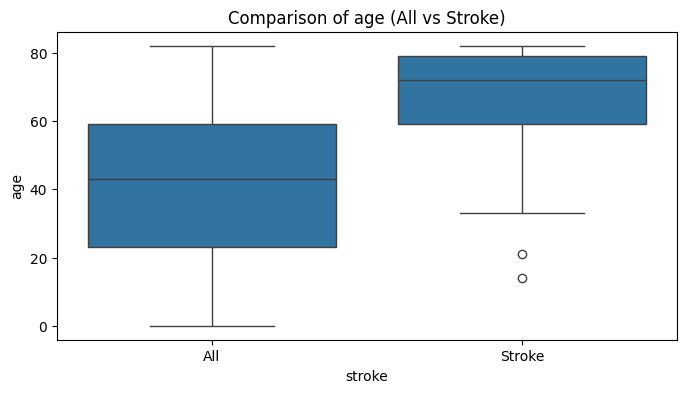

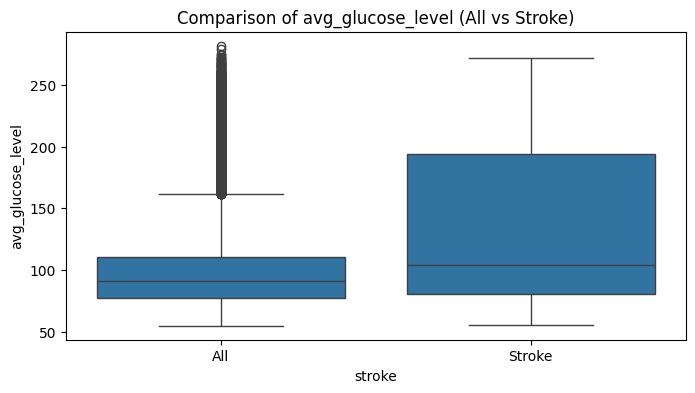

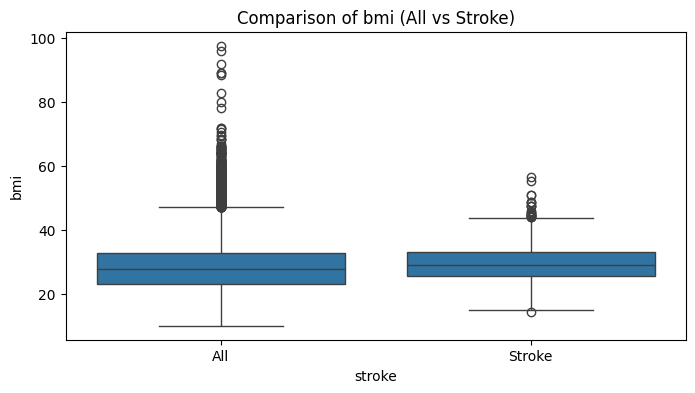

In [122]:
# Boxplot for continuous variables
for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='stroke', y=col, data=df)
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.xticks([0, 1], ['All', 'Stroke'])
    plt.ylabel(col)
    plt.show()

***BMI Comparisson (All vs Stroke)***

- We observe from the plot that people that had a stroke tend to have a slightly higher BMI on average compared to the overall population. BMI is associated with increased health risks, one of which maybe getting a stroke. However as seen in the plot, because the difference in BMI is not extreme, although it may play an important role, it isn't a dominant factor in this machine learning analysis.

***Average Glucose Level Comparison (All vs Stroke)***

- We observe from the plot that people who had a stroke tend to have significantly higher average glucose levels compared to the overall population. Elevated glucose levels are commonly associated with health conditions like diabetes, which is a known risk factor for stroke. The difference in glucose levels between the stroke and non-stroke groups suggests that high glucose levels could be an important indicator of stroke risk. This indicates that glucose monitoring may be very important in assessing stroke risk

## Comparision of patients without stroke vs with stroke for binary columns

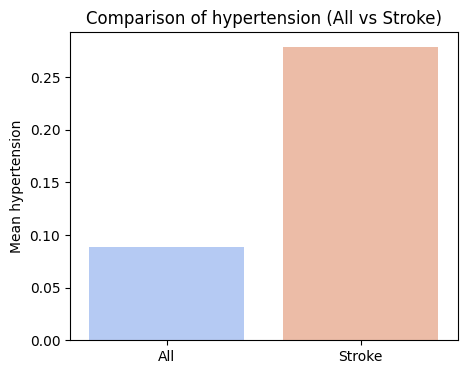

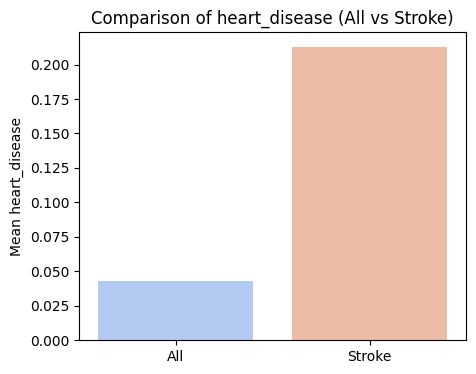

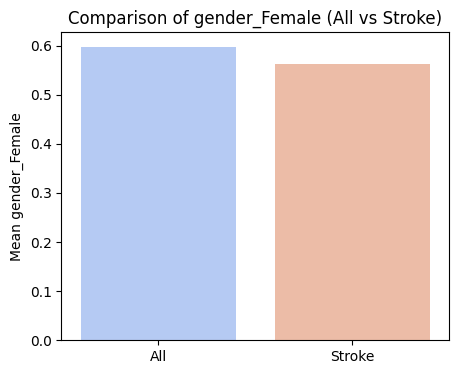

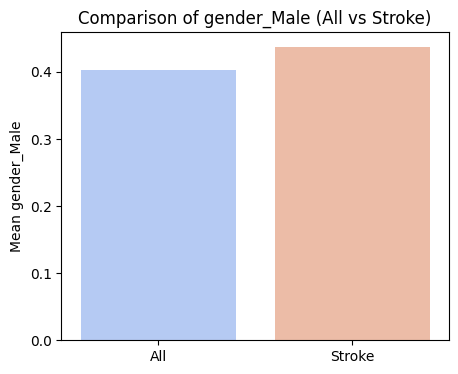

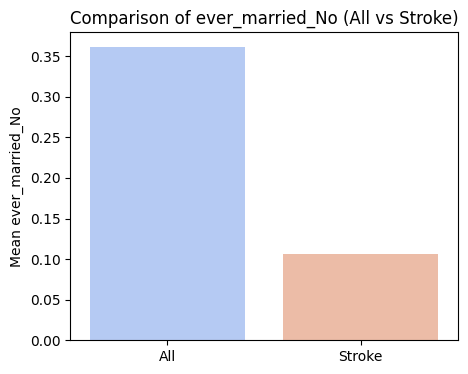

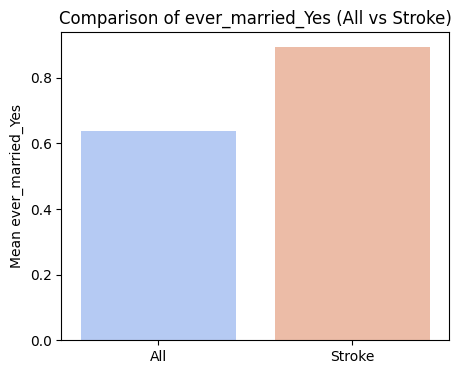

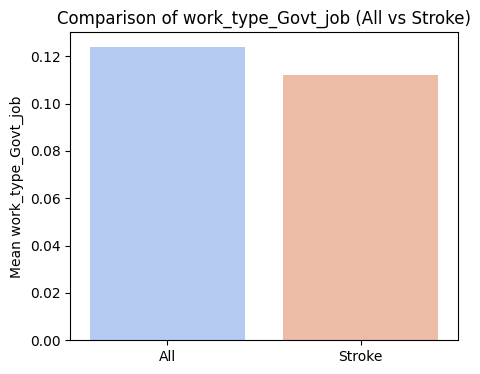

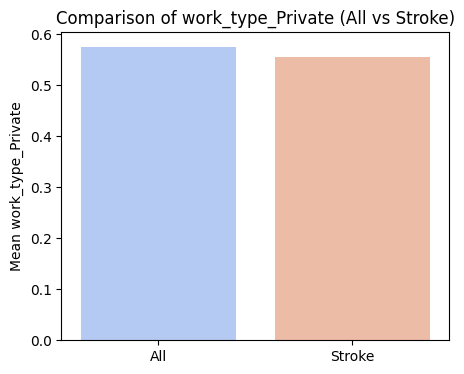

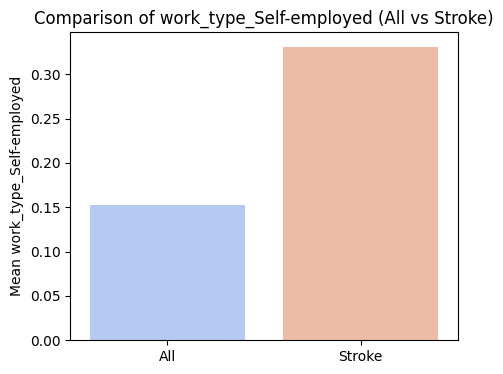

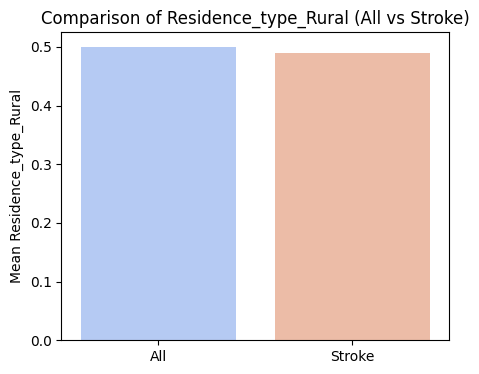

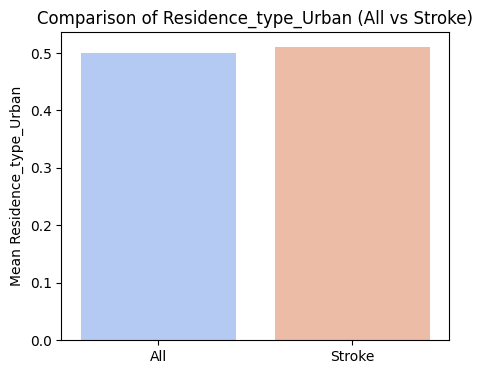

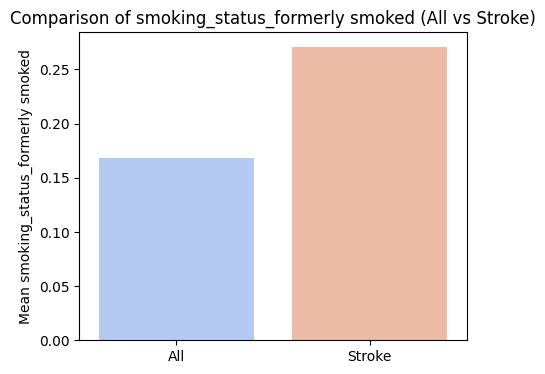

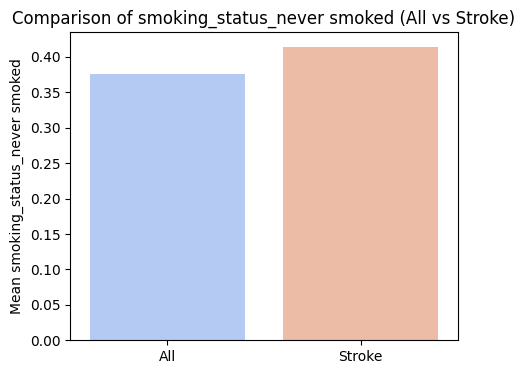

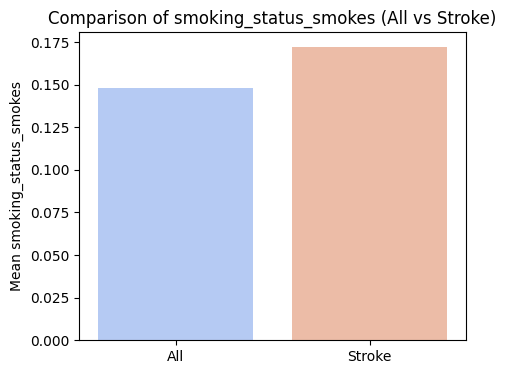

In [123]:
# Barplot for binary variables
for col in binary_cols:
    plt.figure(figsize=(5, 4))
    sns.barplot(x=['All', 'Stroke'], y=[df[col].mean(), df_stroke[col].mean()], palette='coolwarm', hue=['All', 'Stroke'])
    plt.title(f"Comparison of {col} (All vs Stroke)")
    plt.ylabel(f'Mean {col}')
    plt.show()

In [124]:
display(df.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,ever_married_No,ever_married_Yes,work_type_Govt_job,work_type_Private,work_type_Self-employed,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,True,False,False,True,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,True,False,False,True,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,True,False,False,True,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,True,False,False,True,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,True,False,False,True,True,False,True,False,False,0


## REMOVING THE REDUNDANT/DUMMY COLUMNS
The columns are deleted because their information has been merged or transformed into new columns, which simplifies the dataset. This process eliminates redundancy and reduces the number of columns, which can make the data easier to work with and less prone to overfitting in machine learning models.

**Gender:** 
The gender_Female, gender_Male, and gender_Other columns are merged into a single gender column (0 for Female, 1 for Male). The original columns are now redundant.

**Ever Married:**
ever_married_Yes and ever_married_No are combined into a single ever_married column (1 for Yes, 0 for No), making the original columns unnecessary.

**Residence Type:**
The one-hot encoded columns for Residence_type_Rural and Residence_type_Urban are merged into residence_type (0 for Rural, 1 for Urban), so the originals are deleted.

**Work Type:**
The work_type_Self-employed column is simplified into work_type_self_employed (1 for Self-employed, 0 otherwise). The original work type columns are no longer needed.

In [125]:
df = processor.preprocess_gender()
df = processor.preprocess_ever_married()
df = processor.preprocess_residence_type()
df = processor.preprocess_work_type()

display(df.head())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
0,52709,30.0,0,0,63.60,33.3,False,False,True,0,1,0,0,0
1,72295,75.0,1,0,215.17,48.0,False,True,False,0,0,1,0,1
2,26451,15.0,0,0,135.22,19.0,False,True,False,0,1,0,0,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,0,1,1,1,1
4,69299,49.0,0,0,222.34,28.8,True,False,False,0,1,1,0,1


## Changing nominal data to numerical values (needed for ML)

While looking at the data , there are 5 columns that have continuous numerical values like: 'age', 'hypertension', 'heart_disease', 'avg_glucose_level' and 'bmi'. 

The other columns are only true or false statement. If we are going to use these for Machine Learning we need to transform our df to numerical values only.
While we're at it, lets change age to INT instead of FLOAT, as technically speaking you cant be 21 and half.

Transform df into only numerical values.

In [126]:
df = processor.age_to_int()
df = processor.convert_bool_to_int()
display(df.head())


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
0,52709,30,0,0,63.60,33.3,0,0,1,0,1,0,0,0
1,72295,75,1,0,215.17,48.0,0,1,0,0,0,1,0,1
2,26451,15,0,0,135.22,19.0,0,1,0,0,1,0,0,0
3,65210,47,0,0,64.89,28.2,0,1,0,0,1,1,1,1
4,69299,49,0,0,222.34,28.8,1,0,0,0,1,1,0,1


## Here we look at the differences per Gender

In [127]:
df_nostroke = df[df['stroke'] == 1]
df_nostroke.groupby(['gender']).mean()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,ever_married,residence_type,work_type_self_employed
gender,,,,,,,,,,,,,
0,36127.243986,68.725086,0.292096,0.164948,128.032371,29.653265,0.233677,0.515464,0.134021,1.0,0.890034,0.498282,0.319588
1,37807.818584,68.292035,0.261062,0.274336,131.281416,30.174336,0.318584,0.283186,0.221239,1.0,0.898230,0.526549,0.345133


## Heatmap:

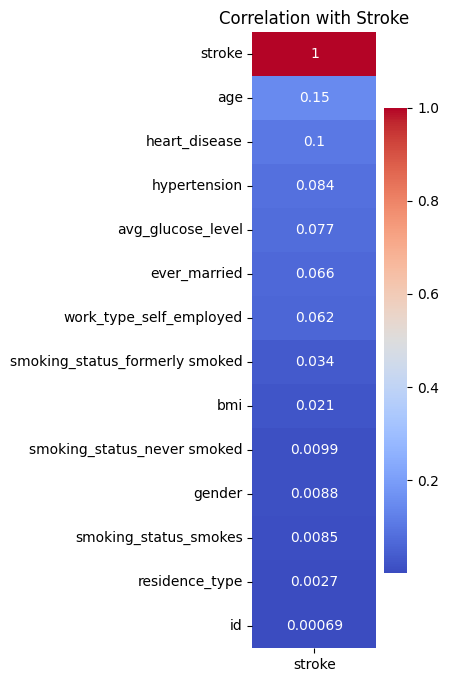

In [128]:
corr_df = df.corr()['stroke'].sort_values(ascending=False).to_frame()

plt.figure(figsize=(2, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', cbar=True)
plt.title('Correlation with Stroke')
plt.show()

# Data cleaning

We will now look at the data (the continuous values) to see if all the data is logical and consistent

In [129]:
df_stroke = df[df['stroke'] == 1]
display(df_stroke.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
28,13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
231,43424,78,0,0,78.81,19.6,0,0,0,1,0,1,0,0
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
283,23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1


### Next we will plot all columns and display boxplots for continuos values and barplots for binary values to inspect the data more closely.

In [130]:
df_nostroke = df[df['stroke'] == 1] 
stroke_count_by_gender = df_nostroke.groupby('gender').size()
display(stroke_count_by_gender)

gender
0    291
1    226
dtype: int64

# @TODO explanation why formerly smoked has a higer risk according to the data for a stroke? is it true.

# @TODO explain why gender. smoking status never smoked, smoking status smokes are getting deleted

In [131]:
columns_to_drop = [
    'gender',
    'smoking_status_never smoked', 
    'smoking_status_smokes'
]
df = processor.drop_columns(columns_to_drop)

print(df.head())

      id  age  hypertension  heart_disease  avg_glucose_level   bmi  \
0  52709   30             0              0              63.60  33.3   
1  72295   75             1              0             215.17  48.0   
2  26451   15             0              0             135.22  19.0   
3  65210   47             0              0              64.89  28.2   
4  69299   49             0              0             222.34  28.8   

   smoking_status_formerly smoked  stroke  ever_married  residence_type  \
0                               0       0             0               0   
1                               0       0             1               0   
2                               0       0             0               0   
3                               0       0             1               1   
4                               1       0             1               0   

   work_type_self_employed  
0                        0  
1                        1  
2                        0  
3     

In [132]:
df_nostroke = df[df['stroke'] == 0]

There are a lot of outliers in the columns bmi & avg_glucose_levels. 
According to general medical knowlege. An assumption we could make is that people with an high BMI, average glucose level get more strokes.

To test this theory, we will find out how many people had a stroke in total, how many people with a high BMI got a stroke and how many 
people with high BMI also got a stroke. 

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
28,13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
231,43424,78,0,0,78.81,19.6,0,0,0,1,0,1,0,0
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
283,23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33244,50049,72,0,1,141.72,33.0,0,0,0,1,1,1,0,0
33284,5095,59,0,0,79.53,29.9,0,1,0,1,1,1,1,1
33315,4809,80,0,0,109.96,19.9,0,1,0,1,0,1,0,0
33328,39373,82,1,0,196.92,22.2,0,1,0,1,0,1,1,1


Median glucose level of stroke patients 104.12
Median glucose level of all patients 91.32
Median age of all patients 43.0
Median age of stroke patients 72.0


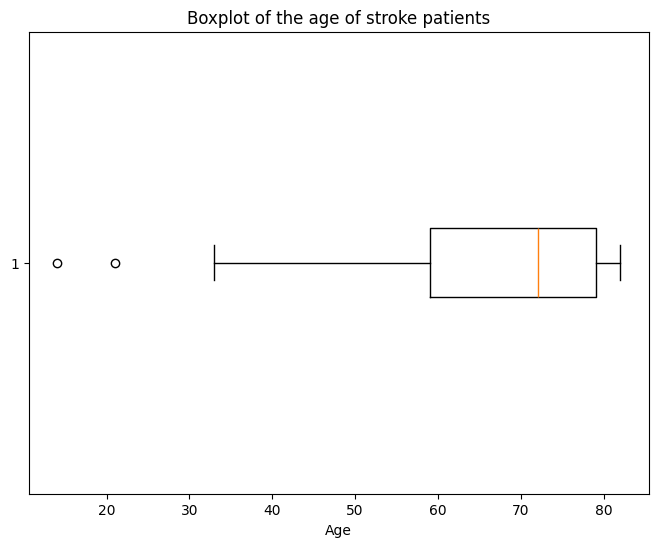

In [133]:
display(df_stroke)

print("Median glucose level of stroke patients" + str(" ") + str(df_stroke['avg_glucose_level'].median()))
print("Median glucose level of all patients" + str(" ") + str(df['avg_glucose_level'].median()))

print("Median age of all patients" + str(" ") + str(df['age'].median()))
print("Median age of stroke patients" + str(" ") + str(df_stroke['age'].median()))


plt.figure(figsize=(8, 6))
plt.boxplot(df_stroke["age"], vert=False)
plt.title("Boxplot of the age of stroke patients")
plt.xlabel("Age")
plt.show()

In [134]:
df_stroke_and_overweight = df_stroke[df_stroke['bmi'] >= 25]
display(df_stroke_and_overweight) 

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
28,13491,80,0,0,259.63,31.7,0,0,1,1,1,1,0,0
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
283,23260,67,0,0,89.59,25.3,0,0,0,1,1,1,1,1
289,11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33147,20426,78,1,0,203.87,45.7,0,1,0,1,0,0,1,0
33202,20067,74,0,0,101.67,27.9,0,1,0,1,0,0,0,0
33244,50049,72,0,1,141.72,33.0,0,0,0,1,1,1,0,0
33284,5095,59,0,0,79.53,29.9,0,1,0,1,1,1,1,1


According to the WHO organization people with a bmi score over 25 are overweight. 
In the dataset there are 517 cases of people who had a stroke. 

When filtering the people who had a stroke and a bmi over 25, which means that they are overweight. We see that 414 people suffered from a stoke.
This strongly indicates that a majority of the patient who are overweight suffered a stroke. 

In conclusion this means that approx. 80% of overweight people also suffered from a stroke according to this dataset.

In [135]:
df_stroke_and_hypertension = df_stroke[df_stroke['hypertension'] == 1]
display(df_stroke_and_hypertension)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke,gender,ever_married,residence_type,work_type_self_employed
216,3512,70,1,0,89.13,34.2,1,0,0,1,0,1,1,1
245,36338,39,1,0,58.09,39.2,0,0,1,1,0,1,0,0
289,11961,57,1,0,196.30,38.6,0,1,0,1,0,1,0,0
616,6660,67,1,0,88.79,27.4,1,0,0,1,1,1,1,1
783,2326,67,1,0,179.12,28.1,1,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32941,53156,73,1,0,77.72,31.4,0,1,0,1,1,1,0,1
32947,36575,81,1,1,65.12,27.4,1,0,0,1,1,0,1,0
33137,34567,81,1,0,74.02,25.0,0,1,0,1,0,1,0,1
33147,20426,78,1,0,203.87,45.7,0,1,0,1,0,0,1,0


### We will apply some basic feature engineering. We will use our medical domain knowledge to create new collumns that tell our ML model which factors indicate a higher risk to have a stroke

For Example, if a patient is over 60 (please refer to our EDA boxplot), the chance to get a stroke is higher. 
but if a patient is over 60 and also has a disease like hypertention or a heart problem, the risk of a stroke can be elevated.
This is the reason why we make new columns that show the compounding effect of these combinations. 

In [136]:
df = processor.add_age_above_60()
df = processor.add_interaction_terms()
df = processor.categorize_bmi()
df = processor.categorize_glucose()

print(df[['age_above_60', 'age_above_60_hypertension', 'age_above_60_heart_disease', 'hypertension_former_smoker', 'bmi_category', 'glucose_category']].head())
display(df)


   age_above_60  age_above_60_hypertension  age_above_60_heart_disease  \
0             0                          0                           0   
1             1                          1                           0   
2             0                          0                           0   
3             0                          0                           0   
4             0                          0                           0   

   hypertension_former_smoker bmi_category glucose_category  
0                           0        obese           normal  
1                           0        obese         diabetic  
2                           0       normal           normal  
3                           0   overweight           normal  
4                           0   overweight         diabetic  


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,smoking_status_formerly smoked,stroke,ever_married,residence_type,work_type_self_employed,age_above_60,age_above_60_hypertension,age_above_60_heart_disease,hypertension_former_smoker,bmi_category,glucose_category
0,52709,30,0,0,63.60,33.3,0,0,0,0,0,0,0,0,0,obese,normal
1,72295,75,1,0,215.17,48.0,0,0,1,0,1,1,1,0,0,obese,diabetic
2,26451,15,0,0,135.22,19.0,0,0,0,0,0,0,0,0,0,normal,normal
3,65210,47,0,0,64.89,28.2,0,0,1,1,1,0,0,0,0,overweight,normal
4,69299,49,0,0,222.34,28.8,1,0,1,0,1,0,0,0,0,overweight,diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,71911,9,0,0,109.80,14.5,0,0,0,0,0,0,0,0,0,underweight,normal
33546,19648,47,0,0,88.61,30.8,0,0,1,1,0,0,0,0,0,obese,normal
33547,35550,3,0,0,89.68,16.2,0,0,0,0,0,0,0,0,0,underweight,normal
33548,65453,56,1,0,82.44,27.8,0,0,1,1,0,0,0,0,0,overweight,normal


In [137]:
df = processor.encode_categories()
df = processor.drop_categorical_columns()

## Decision Tree

*Describe how this model works.*

A decision tree is a machine learning model that helps make decisions by splitting the data into smaller groups based on features in the data. Each questions (or decision) about the data leads to a branch and eventually a final decision is made. The process starts at the root node, where the models chooses the most important feature to split the data first. As the data gets split, additional questions are asked "Is the person with avg_glucose > 215.17?" and then in the last stage (the leaf nodes) a decision (=prediction) is made "Yes, the person will get a stroke.".

The tree decides which feature provides the best split using measures like Gini or Entropy. Through the usage of these both methods the uncertainty of our predictions should be reduced and the groups of data will become more homegenous.


*Describe the criteria on the basis of which the splits in the decision tree can be made. *

There are different criteria, based on which the data can be split - entropy, gini impurity, MSE, MAE, poisson deviance, huber loss, cross-entropy, friedman MSE, laplacian. As we are facing a classification problem and are dealing with categorical labels, we will be using the standart entropy and gini impurity measures to split the data.

As we are dealing with a binary classification problem (no strok=0, stroke=1) and the outcome is categorical (as we are predicting a class label stroke= 0 or 1 based on the other aformentioned features), we will firstly check which hyperparameters are best suited for our dataset. 

To find out which hyperparameter values are best suited and determine the best combination for our decision tree we will be using the GridSearchCV to systematicly test a wide range of hyperparameter values and determine the best combinations for our model.

In [138]:
from sklearn.model_selection import GridSearchCV
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# max depth -> controlls the depth of the tree to avoid overfitting.
# We will try with a shallow tree(5), a slightly deeper one(10) and a relatively deep tree (15)
# min_samples_split -> controls the minimum number of samples needed to split a node
# Higher values (10, 20) prevent the tree from growing too deep.
# min_samples_leaf -> controls the minimum number of samples in a leaf node
# Larger leaf sizes (5, 10) promote generalization and reduce overfitting
# criterion -> the function used to measure the quality of a split (Gini or Entropy)
# gini is faster, while entropy can get better results for complex data.
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=kfold, scoring='f1')
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print(f'Best hyperparameters values are: {best_params}')

NameError: name 'X_train' is not defined

*Explain what 'pruning' is and describe what forms of it have been applied.*
*Explain the relationship between 'pruning' and 'underfitting'.**

Prunning is the process of removing unnecessary branches/nodes from the decision tree to make it simpler and prevent the risk of overfitting the data. There are 2 main types of prooning, pre-prunning this is where we adjusted the max_depth, min_samples_split and min_samples_leaf. In doing so we prevented our tree from growing too large and capturing unnecessary details form the training data. Underfitting on the other hand happens, when the model is too simple to capture specific patterns in the data. Meaning - that if we prune too much our decision tree, by setting for example a overly strict min_samples_split of 50, the tree might become too shallow and fail to learn important relationships, which would lead to underfitting. 


In [ ]:

best_clf = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

best_clf.fit(X_train, y_train)

y_pred_best = best_clf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_best))

# Logistical Regression 

Logistic regression is a statistical model that is used to make a binary decision. This means that it helps to distinguish between two possible outcomes, e.g. in our case, it is about predicting whether a person will suffer a stroke (1) or not (0) based on certain information (e.g. age, glucose level, etc).
#### **How does the model work?**

**Inputs:** We have several characteristics (also called features), such as age, glucose level and BMI. These values are numbers and are given as inputs to the model.

**Calculating the weighting:** Each characteristic has a certain importance, which is determined by so-called "weights". The model multiplies each characteristic by a weight and adds everything together. The result is a number that roughly shows how likely it is that the result is 1 or 0.

**Sigmoid function:** This number is then converted into a probability between 0 and 1 using the logistic function (also known as the sigmoid function). This function ensures that all values fall into the range 0 to 1, which corresponds to a probability.

$$ \text{Sigmoid-Function} = \frac{1}{1 + e^{-z}} $$

*z = the sum of the weighted characteristics*

#### **What is the loss function?**

The loss function measures how well or poorly the model works. The smaller the loss, the better the model works. In logistic regression, we use a special loss function called "Log-Loss".
E.g. if the model predicts for a person that the probability of a stroke is 90%, but the person does not have a stroke, this is a bad prediction and the **loss is high**.
If the model predicts 90% probability for a person and the person actually has a stroke, then the **loss is small** because the prediction was good.
The goal is to minimize the loss for the entire model.

$$ \text{Log-Loss} = - \frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] $$

\( y_i \) *represents the actual labels (either 0 or 1).* 

\( p_i \) *the predicted probability for class 1.*


#### **What is gradient descent in this context?**

Gradient Descent is the method we use to find the best weights for our logistic regression model. The goal is to **minimize the loss function (log-loss)**, which measures how far off the model’s predictions are from the actual values.

**Simple calculation example:**
Let’s say we are predicting whether someone has a stroke based on just age. We start with a random weight, say $\theta = 0.5$, for age.

For one data point, say a 60-year-old person, we calculate $z$, the weighted sum of the input:
$$
z = \theta \times \text{age} = 0.5 \times 60 = 30
$$

Then we apply the **sigmoid function** to get the probability (prediction):

$$
h_\theta(x) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + e^{-30}} \approx 1
$$

So, our model predicts a probability close to 1 (very likely stroke).

**Next steps:**

1. **Calculating the loss:**
If the actual outcome is $y = 0$ (no stroke), we calculate the loss using the log-loss function:

$$
J(\theta) = -[y \log(h_\theta(x)) + (1 - y) \log(1 - h_\theta(x))]
$$

Since $y = 0$, the loss becomes very large because the model predicted the wrong outcome:

$$
J(\theta) \approx -[0 \times \log(1) + (1 - 0) \log(0)] = \infty
$$

2. **Calculating the gradient:**
The gradient shows how much to adjust $\theta$. The gradient for $\theta$ is:

$$
\frac{\partial J(\theta)}{\partial \theta} = (h_\theta(x) - y) \times \text{age}
$$

which equals:

$$
\frac{\partial J(\theta)}{\partial \theta} = (1 - 0) \times 60 = 60
$$

2. **Updating the weights:**
We adjust $\theta$ using the gradient and a learning rate $\alpha$ (say $\alpha = 0.01$):

$$
\theta := \theta - \alpha \times \frac{\partial J(\theta)}{\partial \theta}
$$

So, the new value of $\theta$ becomes:

$$
\theta := 0.5 - 0.01 \times 60 = -0.1
$$

#### **What are the forms of regularization that apply to this model?**

There are two main forms of regularization that apply to logistic regression:

1. **L1 Regularization ("Lasso")**:
- This type of regularization adds a penalty to the model based on the absolute values of the coefficients. It tends to push some coefficients to zero, effectively removing less important features from the model. This helps with feature selection.

- The penalty term for L1 regularization is:

$$ \text{Penalty} = \lambda \sum |\theta_j| $$

2. **L2 Regularization ("Ridge")**:
- L2 regularization adds a penalty proportional to the square of the coefficients. Unlike L1, it doesn’t eliminate features but instead reduces the magnitude of all the coefficients, making the model less sensitive to small variations in the data.

- The penalty term for L2 regularization is:

$$ \text{Penalty} = \frac{\lambda}{2} \sum \theta_j^2 $$

Both of these methods help reduce overfitting by preventing the model from becoming too complex.

#### **How does regularization relate to overfitting?**

Overfitting happens when a model learns not just the meaningful relationships between the features and the target but also the noise (e.g. errors, outliers,..) in the training data. Regularization helps prevent this by penalizing large coefficients.

- **L1 regularization** eliminates unimportant features by pushing their coefficients to zero, reducing the complexity of the model.
- **L2 regularization** keeps all the features but reduces the size of the coefficients, making the model simpler and less prone to fitting the noise in the training data.

Simply put, regularization helps the model perform better on new, unseen data.

#### **At which hyperparameters does the model give the best results?**

The main hyperparameter for regularization is *C*. It controls how strong the regularization is. A **larger *C* value means less regularization**, so the model can fit the training data more closely. A **smaller *C* value increases regularization**, shrinking the coefficients and helping prevent overfitting.

To find the best C-value, you can either use cross-validation tools like *GridSearchCV* to automatically find the optimal value or manually experiment with different values like *C= 0.1, 1.0, 10, 100,..* and see which one gives the best results for your model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Adding regularization: L2 & C=1.0 are the defaults
lr = LogisticRegression(penalty='l2',C=1.0, class_weight='balanced') # "class weighting" technique for imbalanced data
lr.fit(X_train, y_train)

#Making predictions
y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

## K-Nearest Neighbors (KNN)

*Describe how this model works.*

K-Nearest Neighbors (KNN) is a machine learning model used for both classification and regression tasks. The model classifies a new data point by identifying the 'k' data points in the training set that are closest to it, based on a chosen distance metric. Once these neighbors are identified, the KNN model makes a prediction based on the majority label among the neighbors for classification tasks. For regression tasks, the average of the neighboring data points is often used for prediction.

KNN's prediction process looks like this in our stroke prediction scenario: "Is the individual similar in age, BMI, and glucose level to other patients who have had a stroke?" If most of their nearest neighbors have experienced strokes, then the KNN model might predict that this individual is also at risk. By identifying and grouping similar data points, KNN helps provide insights into how close relationships in data influence outcomes.



*Euclidean or Manhattan*

KNN typically uses distance measures like Euclidean or Manhattan distance, with Euclidean distance (straight-line distance between points) being common in most implementations, especially when features are scaled similarly. Manhattan distance, which calculates the sum of absolute differences across dimensions, can be used when features are unevenly scaled.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid for KNN
# n_neighbors: the number of neighbors to consider (smaller values capture more local patterns)
# weights: either uniform weighting or distance-based weighting
# metric: distance metric, with 'euclidean' and 'manhattan' as common choices
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],  # Test different values for k
    'weights': ['uniform', 'distance'],  # Test both uniform and distance weighting
    'metric': ['euclidean', 'manhattan']  # Test different distance metrics
}

# Initialize KNN model
knn = KNeighborsClassifier()

# Initialize GridSearchCV for KNN
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=kfold, scoring='f1')
grid_search_knn.fit(X_train, y_train)

# Get the best hyperparameters and print them
best_params_knn = grid_search_knn.best_params_
print(f'Best hyperparameter values for KNN are: {best_params_knn}')
